In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.4 MB/s eta 0:00:00



image 1/1 /content/car1.jpg: 384x640 1 car, 318.8ms
Speed: 15.1ms preprocess, 318.8ms inference, 40.0ms postprocess per image at shape (1, 3, 384, 640)


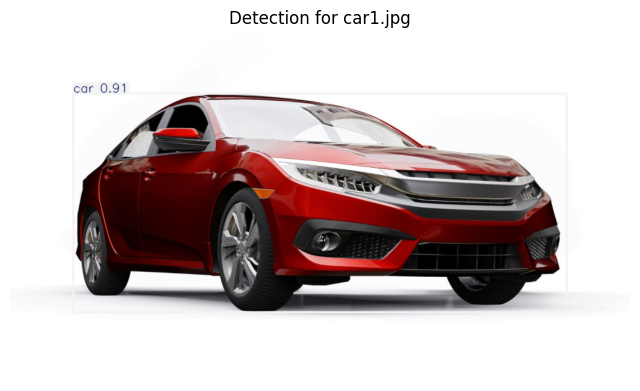

--- Results for car1.jpg ---
Object: car        | Confidence: 0.91 | Coords (xywh): [512.1688232421875, 282.3290710449219, 815.58544921875, 360.80218505859375]

image 1/1 /content/dog1.jpg: 640x544 1 bench, 1 bird, 1 dog, 220.6ms
Speed: 5.8ms preprocess, 220.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 544)


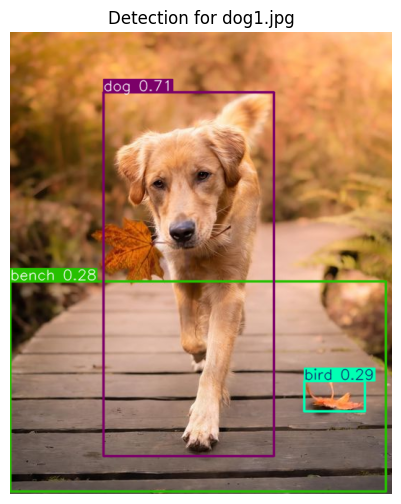

--- Results for dog1.jpg ---
Object: dog        | Confidence: 0.71 | Coords (xywh): [247.55670166015625, 335.4111328125, 236.39080810546875, 504.28369140625]
Object: bird       | Confidence: 0.29 | Coords (xywh): [449.3008117675781, 504.329833984375, 83.93353271484375, 42.2498779296875]
Object: bench      | Confidence: 0.28 | Coords (xywh): [260.0619201660156, 490.787353515625, 520.1238403320312, 290.5167236328125]

image 1/1 /content/house1.jpg: 352x640 1 potted plant, 142.6ms
Speed: 2.9ms preprocess, 142.6ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)


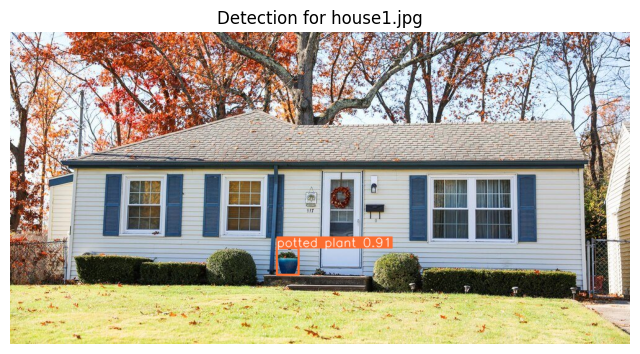

--- Results for house1.jpg ---
Object: potted plant | Confidence: 0.91 | Coords (xywh): [448.3443908691406, 370.7066345214844, 35.1282958984375, 42.89373779296875]


In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# --- 2.1 Basic Object Detection ---
# Load the pre-trained nano model (fast and lightweight)
model = YOLO('yolov8n.pt')

# List of your test images
image_paths = ['car1.jpg', 'dog1.jpg', 'house1.jpg']

for img_path in image_paths:
    # Run inference
    results = model(img_path)

    # Process the results (usually a list with one item per image)
    for r in results:
        # 1. Plot the image with bounding boxes
        im_bgr = r.plot() # Returns a BGR numpy array
        im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib

        plt.figure(figsize=(8, 6))
        plt.imshow(im_rgb)
        plt.axis('off')
        plt.title(f"Detection for {img_path}")
        plt.show()

        # 2. Extract and print details for each detected object
        boxes = r.boxes
        print(f"--- Results for {img_path} ---")
        for box in boxes:
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]
            conf = float(box.conf[0])

            # Extract coordinates in xywh format (x_center, y_center, width, height)
            xywh = box.xywh[0].tolist()

            print(f"Object: {class_name:10} | Confidence: {conf:.2f} | Coords (xywh): {xywh}")

# --- 2.3 Non-Max Suppression (NMS) Customization ---
# You can experiment with different thresholds like this:
# results_custom = model('image1.jpg', conf=0.75, iou=0.3)

In [5]:
pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.0 MB/s eta 0:00:00


In [12]:
from deepface import DeepFace

# --- 3.1 Face Verification ---
# "Are these two faces the same person?"
print("--- Face Verification ---")
# Same person pair
res_same = DeepFace.verify(img1_path="steph4.jpg", img2_path="steph5.jpg", enforce_detection=False)
print(f"Same Person -> Verified: {res_same['verified']} | Distance: {res_same['distance']:.4f}")

# Different person pair
res_diff = DeepFace.verify(img1_path="steph4.jpg", img2_path="lebron1.jpg")
print(f"Diff Person -> Verified: {res_diff['verified']} | Distance: {res_diff['distance']:.4f}")

# --- 3.2 Face Analysis ---
# Predict age, gender, and emotion
print("\n--- Face Analysis ---")
analysis = DeepFace.analyze(img_path="steph4.jpg", actions=['age', 'gender', 'emotion'])
# If multiple faces are detected, it returns a list. We take the first one.
if isinstance(analysis, list):
    analysis = analysis[0]

print(f"Age: {analysis['age']}")
print(f"Gender: {analysis['dominant_gender']}")
print(f"Emotion: {analysis['dominant_emotion']}")

# --- 3.3 Understanding Face Embeddings ---
print("\n--- Face Embeddings ---")
# Extract a numerical vector representing the face
emb_A1 = DeepFace.represent(img_path="steph4.jpg", model_name="Facenet", enforce_detection=False)[0]['embedding']
emb_A2 = DeepFace.represent(img_path="steph5.jpg", model_name="Facenet", enforce_detection=False)[0]['embedding'] # This might still fail if no face is found for embedding
emb_B1 = DeepFace.represent(img_path="lebron1.jpg", model_name="Facenet", enforce_detection=False)[0]['embedding']

print(f"Embedding shape (Facenet): {len(emb_A1)}") # Usually 128 or 512

# Calculate Euclidean distance manually (optional, to show how verify() works)
import numpy as np
dist_same = np.linalg.norm(np.array(emb_A1) - np.array(emb_A2))
dist_diff = np.linalg.norm(np.array(emb_A1) - np.array(emb_B1))

print(f"Euclidean distance (A1 to A2): {dist_same:.4f}")
print(f"Euclidean distance (A1 to B1): {dist_diff:.4f}")

--- Face Verification ---
Same Person -> Verified: True | Distance: 0.1653
Diff Person -> Verified: False | Distance: 0.8759

--- Face Analysis ---


Action: emotion: 100%|██████████| 3/3 [00:01<00:00,  2.62it/s]


Age: 30
Gender: Man
Emotion: happy

--- Face Embeddings ---
Embedding shape (Facenet): 128
Euclidean distance (A1 to A2): 5.4586
Euclidean distance (A1 to B1): 16.1954


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """Two consecutive Conv-BatchNorm-ReLU blocks"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # We use padding=1 to ensure the spatial dimensions don't shrink
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class DownBlock(nn.Module):
    """Downsampling block: MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class UpBlock(nn.Module):
    """Upsampling block: TransposeConv + Concatenate + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Transpose convolution doubles the spatial dimensions and halves the channels
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)

        # After concatenation, channels will be (in_channels // 2) + skip_channels
        # Assuming skip_channels == in_channels // 2, total input to DoubleConv is in_channels
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: input from previous layer (decoder)
        # x2: skip connection input from encoder

        x1 = self.up(x1)

        # Handle cases where dimensions might be slightly off due to odd input shapes
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        # Concatenate along the channel dimension (dim=1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

# --- Deliverable: Testing the shapes ---
print("--- Testing U-Net Blocks ---")
batch_size = 1
channels = 64

# Dummy input representing an image or feature map
x = torch.randn(batch_size, channels, 256, 256)
print(f"Input shape: {x.shape}")

# Test DoubleConv (channels: 64 -> 128, size remains 256x256)
conv_block = DoubleConv(64, 128)
out_conv = conv_block(x)
print(f"After DoubleConv: {out_conv.shape}")

# Test DownBlock (channels: 128 -> 256, size halves to 128x128)
down_block = DownBlock(128, 256)
out_down = down_block(out_conv)
print(f"After DownBlock: {out_down.shape}")

# Test UpBlock
# Let's say out_down is our bottleneck (256 channels, 128x128).
# We want to upsample it and concatenate with out_conv (the skip connection).
# out_down goes up to 256x256 with 128 channels.
# Concatenated with out_conv (128 channels), it becomes 256 channels.
# DoubleConv reduces it back to 64 channels.
up_block = UpBlock(in_channels=256, out_channels=64)
out_up = up_block(x1=out_down, x2=out_conv)
print(f"After UpBlock (with skip connection): {out_up.shape}")

--- Testing U-Net Blocks ---
Input shape: torch.Size([1, 64, 256, 256])
After DoubleConv: torch.Size([1, 128, 256, 256])
After DownBlock: torch.Size([1, 256, 128, 128])
After UpBlock (with skip connection): torch.Size([1, 64, 256, 256])
